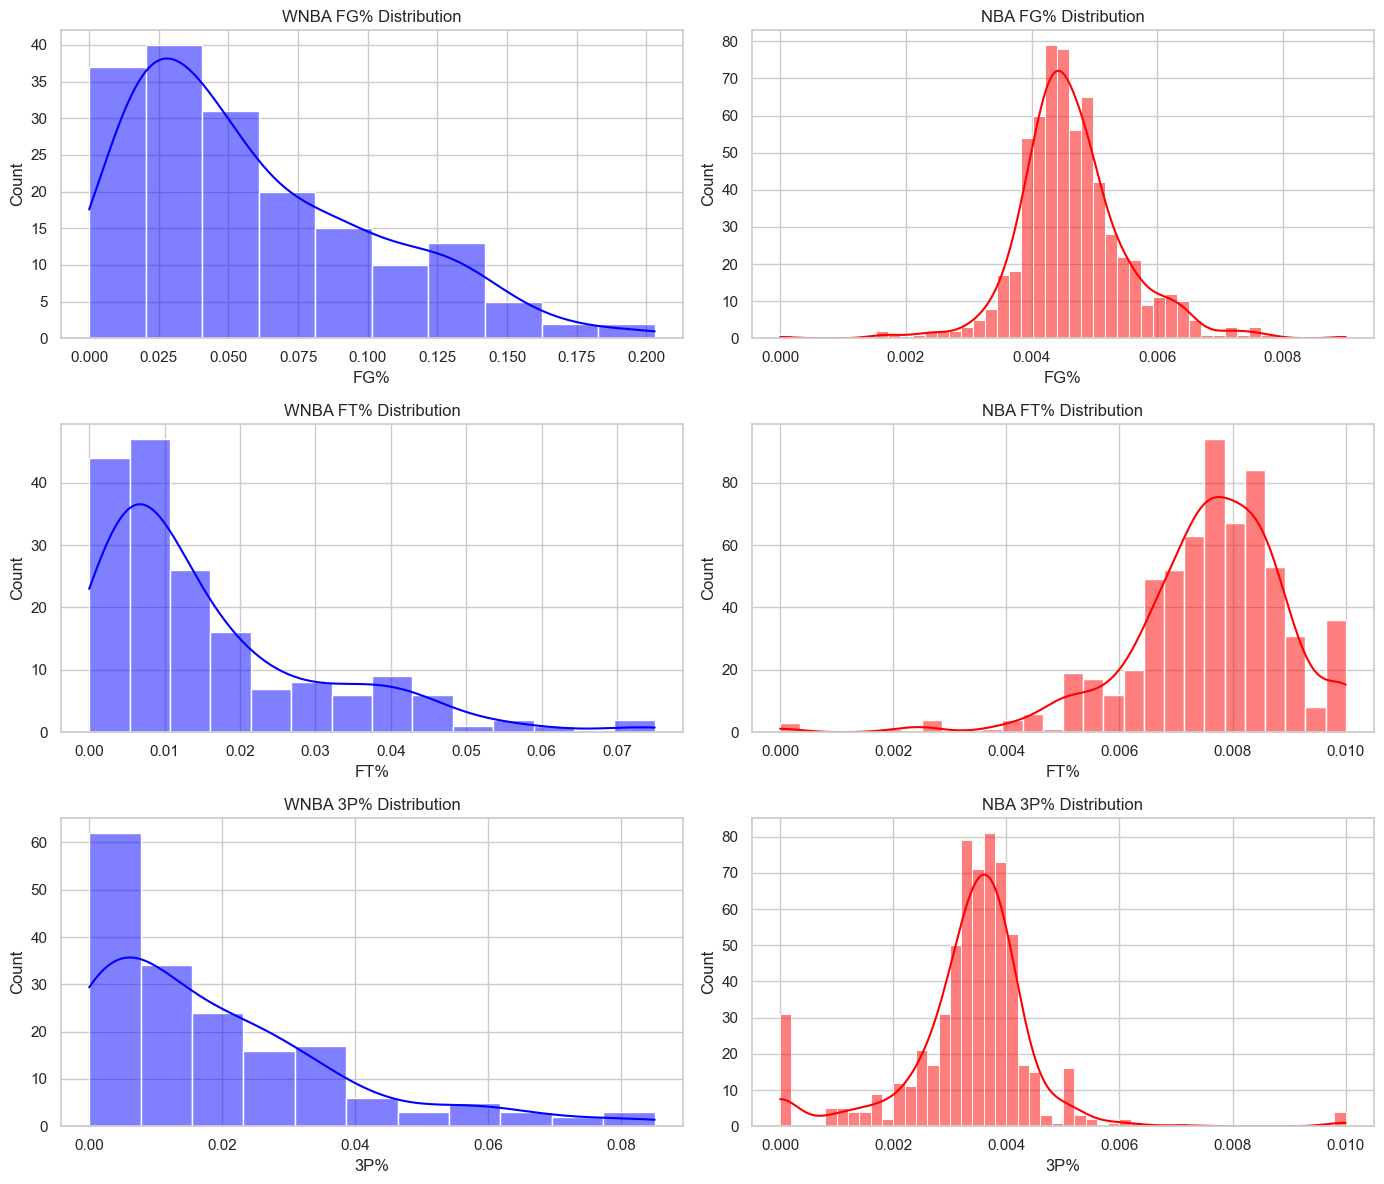

Normality and Variance Homogeneity Summary:
               Test  WNBA Statistic  WNBA p-value  NBA Statistic  \
0  Shapiro-Wilk FG%          0.9138  1.250000e-08         0.9463   
1  Shapiro-Wilk FT%          0.8372  1.070000e-12         0.9197   
2  Shapiro-Wilk 3P%          0.8592  1.090000e-11         0.8354   
3        Levene FG%             NaN           NaN       842.4670   
4        Levene FT%             NaN           NaN       411.3340   
5        Levene 3P%             NaN           NaN       562.3170   

     NBA p-value  
0   2.830000e-14  
1   1.010000e-17  
2   6.940000e-25  
3  5.270000e-127  
4   4.440000e-74  
5   1.650000e-94  


/var/folders/1x/x5_kmnm14kd528k7cn8h9ywr0000gn/T/ipykernel_2005/4254661429.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='League', y='FG%', data=data, palette="Set3")
/var/folders/1x/x5_kmnm14kd528k7cn8h9ywr0000gn/T/ipykernel_2005/4254661429.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='League', y='FT%', data=data, palette="Set3")
/var/folders/1x/x5_kmnm14kd528k7cn8h9ywr0000gn/T/ipykernel_2005/4254661429.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='League', y='3P%', data=data, palette="Set3")


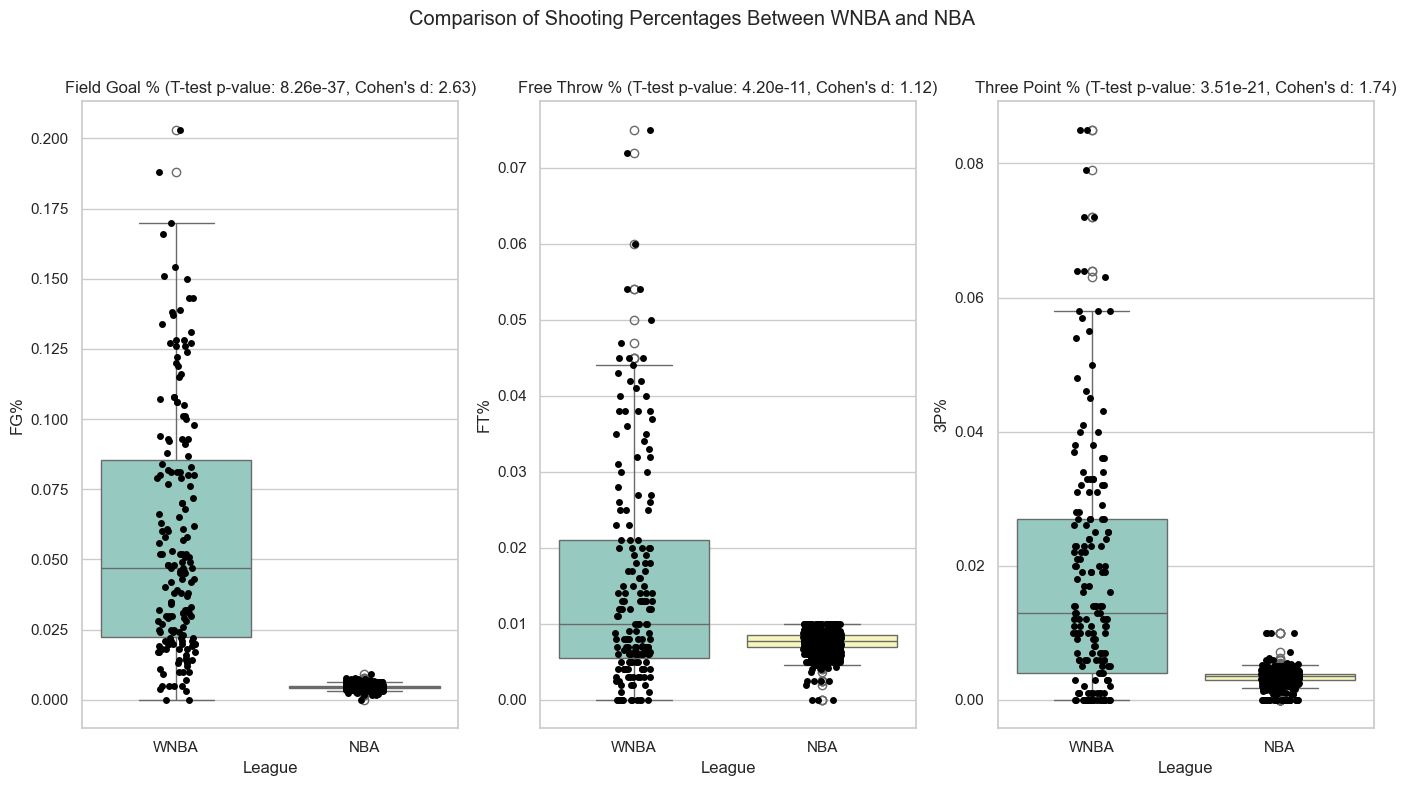

Effect Size and Mann-Whitney U Summary:
       Statistic  Cohen's d  Mann-Whitney U Statistic  Mann-Whitney U p-value
0   Field Goal %       2.63                  106344.0            1.790000e-81
1   Free Throw %       1.12                   64783.0            1.870000e-04
2  Three Point %       1.74                   84232.0            7.720000e-28


In [2]:
# notebooks/statistical_analysis.ipynb

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Load the combined data
data = pd.read_csv('../data/combined_data.csv')

# Setting up the plot style
sns.set(style="whitegrid")

# --- 1. Visualizing the Distribution ---
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Field Goal %
sns.histplot(data[data['League'] == 'WNBA']['FG%'], kde=True, ax=axes[0, 0], color="blue")
sns.histplot(data[data['League'] == 'NBA']['FG%'], kde=True, ax=axes[0, 1], color="red")
axes[0, 0].set_title("WNBA FG% Distribution")
axes[0, 1].set_title("NBA FG% Distribution")

# Free Throw %
sns.histplot(data[data['League'] == 'WNBA']['FT%'], kde=True, ax=axes[1, 0], color="blue")
sns.histplot(data[data['League'] == 'NBA']['FT%'], kde=True, ax=axes[1, 1], color="red")
axes[1, 0].set_title("WNBA FT% Distribution")
axes[1, 1].set_title("NBA FT% Distribution")

# Three Point %
sns.histplot(data[data['League'] == 'WNBA']['3P%'], kde=True, ax=axes[2, 0], color="blue")
sns.histplot(data[data['League'] == 'NBA']['3P%'], kde=True, ax=axes[2, 1], color="red")
axes[2, 0].set_title("WNBA 3P% Distribution")
axes[2, 1].set_title("NBA 3P% Distribution")

plt.tight_layout()
plt.show()

# --- 2. Summarize Normality and Variance Homogeneity ---
# Summary of Shapiro-Wilk and Levene's Test Results
summary_table = pd.DataFrame({
    'Test': ['Shapiro-Wilk FG%', 'Shapiro-Wilk FT%', 'Shapiro-Wilk 3P%', 'Levene FG%', 'Levene FT%', 'Levene 3P%'],
    'WNBA Statistic': [0.9138, 0.8372, 0.8592, np.nan, np.nan, np.nan],
    'WNBA p-value': [1.25e-08, 1.07e-12, 1.09e-11, np.nan, np.nan, np.nan],
    'NBA Statistic': [0.9463, 0.9197, 0.8354, 842.467, 411.334, 562.317],
    'NBA p-value': [2.83e-14, 1.01e-17, 6.94e-25, 5.27e-127, 4.44e-74, 1.65e-94]
})

print("Normality and Variance Homogeneity Summary:")
print(summary_table)

# --- 3. Visualizing T-Test Results ---
plt.figure(figsize=(14, 8))

# Field Goal %
plt.subplot(1, 3, 1)
sns.boxplot(x='League', y='FG%', data=data, palette="Set3")
sns.stripplot(x='League', y='FG%', data=data, color='black', jitter=True)
plt.title(f'Field Goal % (T-test p-value: 8.26e-37, Cohen\'s d: 2.63)')

# Free Throw %
plt.subplot(1, 3, 2)
sns.boxplot(x='League', y='FT%', data=data, palette="Set3")
sns.stripplot(x='League', y='FT%', data=data, color='black', jitter=True)
plt.title(f'Free Throw % (T-test p-value: 4.20e-11, Cohen\'s d: 1.12)')

# Three Point %
plt.subplot(1, 3, 3)
sns.boxplot(x='League', y='3P%', data=data, palette="Set3")
sns.stripplot(x='League', y='3P%', data=data, color='black', jitter=True)
plt.title(f'Three Point % (T-test p-value: 3.51e-21, Cohen\'s d: 1.74)')

plt.suptitle('Comparison of Shooting Percentages Between WNBA and NBA')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- 4. Effect Size and Non-parametric Test Summary ---
# Effect size and Mann-Whitney U summary
effect_size_table = pd.DataFrame({
    'Statistic': ['Field Goal %', 'Free Throw %', 'Three Point %'],
    'Cohen\'s d': [2.63, 1.12, 1.74],
    'Mann-Whitney U Statistic': [106344.0, 64783.0, 84232.0],
    'Mann-Whitney U p-value': [1.79e-81, 1.87e-04, 7.72e-28]
})

print("Effect Size and Mann-Whitney U Summary:")
print(effect_size_table)
